In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import japanize_matplotlib
from pybea.client import BureauEconomicAnalysisClient

import os

bea_client = BureauEconomicAnalysisClient(api_key=os.environ.get('BEA_API_KEY'))

y_start = 2007
y_end = 2026

In [2]:
def bea_get_data(arg_table, arg_start, arg_end, arg_freq):
    res = bea_client.national_income_and_product_accounts_detail(
        table_name=arg_table,
        frequency=[arg_freq],
        year=[str(i) for i in range(int(arg_start), int(arg_end) + 1)]
    )

    data = res['BEAAPI']['Results']['Data']
    data = pd.DataFrame(data)

    data.loc[:, 'LineNumber'] = [str(i).zfill(3) for i in data['LineNumber'].tolist()]
    data.loc[:, 'DataValue'] = [str(s).replace(',', '') for s in data.loc[:, 'DataValue'].tolist()]
    data.loc[:, 'DataValue'] = data.loc[:, 'DataValue'].astype('float64')

    data = pd.pivot_table(
        data,
        index=['LineNumber', 'SeriesCode', 'LineDescription'],
        columns='TimePeriod',
        values='DataValue'
    )

    return data

## 1. BEAデータ取得

In [3]:
prices = bea_get_data("U20404", y_start, y_end, "M")
nominals = bea_get_data("U20405", y_start, y_end, "M")

prices.to_excel("prices.xlsx")
nominals.to_excel("nominals.xlsx")

https://apps.bea.gov/api/data/?userid=3CEFA011-1C00-4C2C-8DC0-93554C0A7639&method=GetData&datasetname=NIUnderlyingDetail&year=2007%2C2008%2C2009%2C2010%2C2011%2C2012%2C2013%2C2014%2C2015%2C2016%2C2017%2C2018%2C2019%2C2020%2C2021%2C2022%2C2023%2C2024%2C2025%2C2026&resultformat=JSON&frequency=M&tablename=U20404
https://apps.bea.gov/api/data/?userid=3CEFA011-1C00-4C2C-8DC0-93554C0A7639&method=GetData&datasetname=NIUnderlyingDetail&year=2007%2C2008%2C2009%2C2010%2C2011%2C2012%2C2013%2C2014%2C2015%2C2016%2C2017%2C2018%2C2019%2C2020%2C2021%2C2022%2C2023%2C2024%2C2025%2C2026&resultformat=JSON&frequency=M&tablename=U20405


In [4]:
def load_pce_wide_excel(path):
    df = pd.read_excel(path)
    df['LineNumber'] = df['LineNumber'].astype(int).astype(str).str.zfill(3)
    return df

prices_raw = load_pce_wide_excel("prices.xlsx")
nominals_raw = load_pce_wide_excel("nominals.xlsx")

## 2. INDENT表読み込み

In [5]:
def load_indent_table(path):
    raw = pd.read_excel(path, header=None)

    df = raw.iloc[:, [0, 1, 11]].copy()
    df.columns = ['LineNumber', 'LineDescription', 'Indent']

    df = df[pd.to_numeric(df['LineNumber'], errors='coerce').notna()].copy()
    df['LineNumber'] = df['LineNumber'].astype(int)

    df = df[(df['LineNumber'] >= 1) & (df['LineNumber'] <= 368)].copy()

    df['LineNumber'] = df['LineNumber'].astype(str).str.zfill(3)
    df['LineDescription'] = df['LineDescription'].astype(str).str.strip()
    df['Indent'] = pd.to_numeric(df['Indent'], errors='coerce')

    return df.reset_index(drop=True)
indent_df = load_indent_table("Table (6).xlsx")

## 3. リーフ抽出：NaNリーフは親項目に置換

In [6]:
def get_leaf_lines_by_indent(
    indent_df,
    max_line=368,
    exclude_less_branch=True,
    prices_raw=prices_raw,
    nominals_raw=nominals_raw
):
    df = indent_df.copy()
    df['LineNumber'] = df['LineNumber'].astype(str).str.zfill(3)
    df['Indent'] = pd.to_numeric(df['Indent'], errors='coerce')
    df['LineDescription'] = df['LineDescription'].astype(str)

    df = df[
        (df['LineNumber'].astype(int) >= 1)
        & (df['LineNumber'].astype(int) <= max_line)
    ].reset_index(drop=True)

    month_cols = [c for c in prices_raw.columns if str(c).startswith('20') and 'M' in str(c)]

    price_lines = set(prices_raw['LineNumber'].astype(str).str.zfill(3))
    nominal_lines = set(nominals_raw['LineNumber'].astype(str).str.zfill(3))

    def line_has_nan(line):
        line = str(line).zfill(3)

        if line not in price_lines or line not in nominal_lines:
            return True

        p = prices_raw.loc[
            prices_raw['LineNumber'].astype(str).str.zfill(3) == line,
            month_cols
        ]

        n = nominals_raw.loc[
            nominals_raw['LineNumber'].astype(str).str.zfill(3) == line,
            month_cols
        ]

        if p.empty or n.empty:
            return True

        return (
            p.isna().any(axis=1).iloc[0]
            or n.isna().any(axis=1).iloc[0]
        )

    children = {i: [] for i in df.index}
    parent = {i: None for i in df.index}

    stack = []

    for i, row in df.iterrows():
        indent = row['Indent']

        while stack and df.loc[stack[-1], 'Indent'] >= indent:
            stack.pop()

        if stack:
            parent[i] = stack[-1]
            children[stack[-1]].append(i)

        stack.append(i)

    in_less_branch = set()

    for i, row in df.iterrows():
        desc = row['LineDescription'].strip().lower()

        if desc.startswith('less:'):
            less_indent = row['Indent']
            in_less_branch.add(i)

            j = i + 1
            while j < len(df) and df.loc[j, 'Indent'] > less_indent:
                in_less_branch.add(j)
                j += 1

    replacements = []

    def select_node(i):
        line = df.loc[i, 'LineNumber']

        if exclude_less_branch and i in in_less_branch:
            return []

        # リーフ
        if len(children[i]) == 0:
            if line_has_nan(line):
                return None
            return [line]

        selected = []

        for child in children[i]:
            child_selected = select_node(child)

            # 子孫リーフにNaNがあれば、このノードで止める
            if child_selected is None:
                if line_has_nan(line):
                    return None

                replacements.append({
                    'replacement_line': line,
                    'replacement_desc': df.loc[i, 'LineDescription']
                })

                return [line]

            selected.extend(child_selected)

        return selected

    root_idx = df.index[df['LineNumber'] == '001'][0]
    item_lines = select_node(root_idx)

    if item_lines is None:
        raise ValueError("Root item also contains NaN. Cannot construct item lines.")

    excluded_less_lines = []

    for i in in_less_branch:
        if len(children[i]) == 0:
            excluded_less_lines.append(df.loc[i, 'LineNumber'])

    item_lines = list(dict.fromkeys(item_lines))

    get_leaf_lines_by_indent.replacements = (
        pd.DataFrame(replacements).drop_duplicates()
        if len(replacements) > 0
        else pd.DataFrame(columns=['replacement_line', 'replacement_desc'])
    )

    return item_lines, excluded_less_lines
item_lines, excluded_less_lines = get_leaf_lines_by_indent(
    indent_df,
    max_line=368,
    exclude_less_branch=True
)

print("number of selected lines:", len(item_lines))
print("excluded Less lines:", excluded_less_lines)
display(get_leaf_lines_by_indent.replacements)

number of selected lines: 227
excluded Less lines: ['274', '149', '339', '340', '341', '358', '359', '360', '361', '362', '363', '364', '365', '366', '367', '368']


,replacement_line,replacement_desc
0,156,Tenant-occupied stationary homes and landlord ...


## 4. Wide行列化

In [7]:
def wide_to_matrix(df, item_lines):
    item_lines = [str(x).zfill(3) for x in item_lines]

    month_cols = [c for c in df.columns if str(c).startswith('20') and 'M' in str(c)]

    out = df[df['LineNumber'].isin(item_lines)].copy()
    out = out.set_index('LineNumber')[month_cols].T

    out.index = pd.PeriodIndex(
        [str(x).replace('M', '-') for x in out.index],
        freq='M'
    )

    return out.astype(float)

## 5. Less控除を兄弟側の正項目に比例配分

In [8]:
def allocate_less_to_sibling_positive_leaves(indent_df, nominals_raw, item_lines):
    df = indent_df.copy()
    df['LineNumber'] = df['LineNumber'].astype(str).str.zfill(3)
    df['Indent'] = pd.to_numeric(df['Indent'], errors='coerce')
    df['LineDescription'] = df['LineDescription'].astype(str)
    df = df.reset_index(drop=True)

    item_lines = [str(x).zfill(3) for x in item_lines]

    nom_adj = wide_to_matrix(nominals_raw, item_lines).copy()

    less_rows = df[
        df['LineDescription'].str.strip().str.lower().str.startswith('less:')
    ]

    for less_idx, less_row in less_rows.iterrows():
        less_line = less_row['LineNumber']
        less_indent = less_row['Indent']

        # Less行の親
        parent_idx = None

        for i in range(less_idx - 1, -1, -1):
            if df.loc[i, 'Indent'] < less_indent:
                parent_idx = i
                break

        if parent_idx is None:
            continue

        parent_indent = df.loc[parent_idx, 'Indent']

        # 親ブランチ全体
        branch_idx = []
        j = parent_idx + 1

        while j < len(df) and df.loc[j, 'Indent'] > parent_indent:
            branch_idx.append(j)
            j += 1

        # Lessブランチ
        less_branch_idx = [less_idx]
        j = less_idx + 1

        while j < len(df) and df.loc[j, 'Indent'] > less_indent:
            less_branch_idx.append(j)
            j += 1

        less_branch_lines = set(df.loc[less_branch_idx, 'LineNumber'])

        # Lessブランチ外にある採用済み項目へ配分
        target_lines = [
            df.loc[i, 'LineNumber']
            for i in branch_idx
            if df.loc[i, 'LineNumber'] in item_lines
            and df.loc[i, 'LineNumber'] not in less_branch_lines
        ]

        if len(target_lines) == 0:
            continue

        less_nom = wide_to_matrix(nominals_raw, [less_line]).iloc[:, 0]

        base = nom_adj[target_lines].sum(axis=1)

        for line in target_lines:
            share = nom_adj[line] / base
            nom_adj[line] = nom_adj[line] - less_nom * share

    return nom_adj

prices_items = wide_to_matrix(prices_raw, item_lines)

nominals_items = allocate_less_to_sibling_positive_leaves(
    indent_df=indent_df,
    nominals_raw=nominals_raw,
    item_lines=item_lines
)

headline_pce = wide_to_matrix(prices_raw, ['001'])
headline_pce.columns = ['headline PCED']

## 6. カバレッジ確認

0.9999990815330273 1.0000008838878733 0.9999999101140563


<Axes: title={'center': 'Coverage after Less allocation'}>

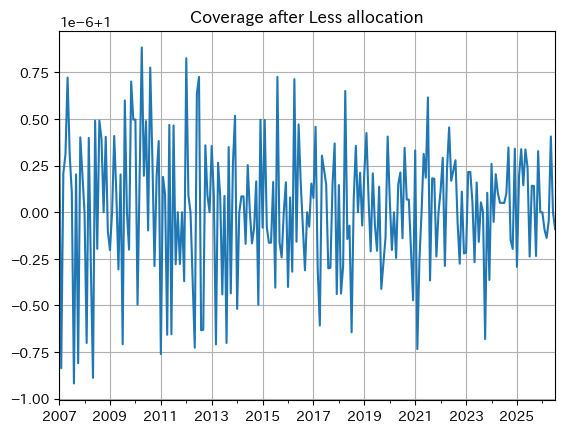

In [9]:
headline_nominal = wide_to_matrix(nominals_raw, ['001']).iloc[:, 0]

coverage = nominals_items.sum(axis=1) / headline_nominal

print(coverage.min(), coverage.max(), coverage.iloc[-1])

coverage.plot(
    grid=True,
    title='Coverage after Less allocation'
)

## 7. インフレ率関数

In [10]:
def g_ann(arg_df, nn):
    return ((arg_df / arg_df.shift(nn)) ** (12 / nn) - 1) * 100
def forward_ann(arg_df, nn):
    return ((arg_df.shift(-nn) / arg_df) ** (12 / nn) - 1) * 100

## 8. 刈り込み平均PCE

In [11]:
def make_trimmed_mean_pce(
    arg_prices,
    arg_nominals,
    lower_trim=0.08,
    upper_trim=0.24,
    label='trimmed mean PCED'
):
    if lower_trim < 0 or upper_trim < 0:
        raise ValueError("lower_trim and upper_trim must be non-negative.")

    if lower_trim + upper_trim >= 1:
        raise ValueError("lower_trim + upper_trim must be less than 1.")

    common_cols = [c for c in arg_prices.columns if c in arg_nominals.columns]

    p = arg_prices.loc[:, common_cols].copy()
    n = arg_nominals.loc[:, common_cols].copy()

    infl = np.log(p).diff()

    w = n.shift(1)
    w = w.div(w.sum(axis=1), axis=0)

    trimmed_infl = pd.Series(index=infl.index, dtype='float64')

    for t in infl.index:

        df = pd.concat([infl.loc[t], w.loc[t]], axis=1)
        df.columns = ['infl', 'weight']
        df = df.dropna()
        df = df[df['weight'] > 0]

        if df.empty:
            continue

        df['weight'] = df['weight'] / df['weight'].sum()

        df = df.sort_values('infl')

        df['cum_weight_before'] = df['weight'].cumsum() - df['weight']
        df['cum_weight_after'] = df['weight'].cumsum()

        lower_bound = lower_trim
        upper_bound = 1 - upper_trim

        df['kept_weight'] = (
            np.minimum(df['cum_weight_after'], upper_bound)
            - np.maximum(df['cum_weight_before'], lower_bound)
        ).clip(lower=0)

        if df['kept_weight'].sum() == 0:
            continue

        trimmed_infl.loc[t] = (
            df['infl'] * df['kept_weight']
        ).sum() / df['kept_weight'].sum()

    out = pd.DataFrame(index=trimmed_infl.index, columns=[label], dtype='float64')

    valid = trimmed_infl.dropna()

    if valid.empty:
        return out

    first_valid = valid.index[0]
    out.loc[first_valid, label] = 100.0

    last_value = 100.0

    for t in valid.index[1:]:
        last_value = last_value * np.exp(trimmed_infl.loc[t])
        out.loc[t, label] = last_value

    return out

## 9. 刈り込み幅探索

In [12]:
def search_trim_widths(
    arg_prices,
    arg_nominals,
    headline_index,
    lower_grid=[0.10, 0.15, 0.20, 0.25, 0.30],
    upper_grid=[0.10, 0.15, 0.20, 0.25, 0.30],
    signal_horizon=3,
    target_horizon=12,
    sample_start='2010-01',
    max_total_trim=0.60
):
    arg_prices = arg_prices.copy()
    arg_nominals = arg_nominals.copy()
    headline_index = headline_index.copy()

    if not isinstance(arg_prices.index, pd.PeriodIndex):
        arg_prices.index = pd.PeriodIndex(arg_prices.index, freq='M')

    if not isinstance(arg_nominals.index, pd.PeriodIndex):
        arg_nominals.index = pd.PeriodIndex(arg_nominals.index, freq='M')

    if not isinstance(headline_index.index, pd.PeriodIndex):
        headline_index.index = pd.PeriodIndex(headline_index.index, freq='M')

    sample_start = pd.Period(sample_start, freq='M')

    target = forward_ann(headline_index, target_horizon)
    target = target.iloc[:, [0]]
    target.columns = ['target_headline']

    results = []

    for lower_trim in lower_grid:
        for upper_trim in upper_grid:

            if lower_trim + upper_trim > max_total_trim:
                continue

            label = f'trim_{int(lower_trim * 100)}_{int(upper_trim * 100)}'

            trimmed_index = make_trimmed_mean_pce(
                arg_prices=arg_prices,
                arg_nominals=arg_nominals,
                lower_trim=lower_trim,
                upper_trim=upper_trim,
                label=label
            )

            signal = g_ann(trimmed_index, signal_horizon)
            signal = signal.iloc[:, [0]]
            signal.columns = ['signal']

            df = pd.concat([signal, target], axis=1, join='inner')
            df = df.loc[sample_start:, :].dropna()

            if df.empty:
                continue

            error = df['signal'] - df['target_headline']

            results.append({
                'lower_trim': lower_trim,
                'upper_trim': upper_trim,
                'total_trim': lower_trim + upper_trim,
                'kept_share': 1 - lower_trim - upper_trim,
                'rmse': np.sqrt((error ** 2).mean()),
                'mae': error.abs().mean(),
                'bias': error.mean(),
                'corr': df[['signal', 'target_headline']].corr().iloc[0, 1],
                'vol': df['signal'].std(),
                'nobs': df.shape[0]
            })

    out = pd.DataFrame(results)

    if out.empty:
        raise ValueError("No valid trim candidates. Check selected lines and missing values.")

    out['rank_rmse'] = out['rmse'].rank(method='min')
    out['rank_mae'] = out['mae'].rank(method='min')
    out['rank_abs_bias'] = out['bias'].abs().rank(method='min')
    out['rank_corr'] = (-out['corr']).rank(method='min')
    out['rank_vol'] = out['vol'].rank(method='min')

    out['score'] = (
        0.50 * out['rank_rmse']
        + 0.20 * out['rank_mae']
        + 0.15 * out['rank_abs_bias']
        + 0.10 * out['rank_corr']
        + 0.05 * out['rank_vol']
    )

    return out.sort_values('score').reset_index(drop=True)

## 10. 実行

In [13]:
trim_search = search_trim_widths(
    arg_prices=prices_items,
    arg_nominals=nominals_items,
    headline_index=headline_pce,
    lower_grid=[0.10, 0.15, 0.20, 0.25, 0.30],
    upper_grid=[0.10, 0.15, 0.20, 0.25, 0.30],
    signal_horizon=3,
    target_horizon=12,
    sample_start='2010-01',
    max_total_trim=0.60
)

trim_search.head(10)

,lower_trim,upper_trim,total_trim,kept_share,rmse,mae,bias,corr,vol,nobs,rank_rmse,rank_mae,rank_abs_bias,rank_corr,rank_vol,score
0,0.10,0.10,0.20,0.80,1.328672,1.004324,0.027653,0.586461,1.271956,187,1.0,3.0,1.0,5.0,18.0,2.65
1,0.15,0.15,0.30,0.70,1.369461,1.035011,0.086310,0.545989,1.189492,187,2.0,7.0,3.0,8.0,14.0,4.35
2,0.10,0.15,0.25,0.75,1.407420,0.983417,-0.370738,0.547166,1.156005,187,3.0,1.0,10.0,6.0,13.0,4.45
3,0.15,0.20,0.35,0.65,1.414634,0.996070,-0.206541,0.506279,1.102738,187,4.0,2.0,8.0,12.0,9.0,5.25
4,0.20,0.20,0.40,0.60,1.417715,1.079109,0.140938,0.505036,1.145317,187,5.0,11.0,5.0,13.0,12.0,7.35
5,0.20,0.25,0.45,0.55,1.442557,1.031298,-0.101837,0.468510,1.073922,187,7.0,6.0,4.0,18.0,8.0,7.50
6,0.15,0.10,0.25,0.75,1.422009,1.170553,0.482586,0.587251,1.311017,187,6.0,15.0,15.0,4.0,21.0,9.70
7,0.25,0.30,0.55,0.45,1.478937,1.065671,-0.042517,0.431699,1.060448,187,10.0,9.0,2.0,24.0,6.0,9.80
8,0.25,0.25,0.50,0.50,1.469806,1.122437,0.177930,0.463278,1.129423,187,9.0,12.0,6.0,19.0,11.0,10.25
9,0.20,0.15,0.35,0.65,1.443412,1.172557,0.430604,0.546464,1.236031,187,8.0,16.0,13.0,7.0,17.0,10.70


## 11. 最終系列作成

In [14]:
best_lower = trim_search.loc[0, 'lower_trim']
best_upper = trim_search.loc[0, 'upper_trim']

true_inflation_pce = make_trimmed_mean_pce(
    arg_prices=prices_items,
    arg_nominals=nominals_items,
    lower_trim=best_lower,
    upper_trim=best_upper,
    label='true inflation PCED'
)

print(f"lower trim = {best_lower:.0%}")
print(f"upper trim = {best_upper:.0%}")
print(f"kept share = {1 - best_lower - best_upper:.0%}")
print(true_inflation_pce.notna().sum())


lower trim = 10%
upper trim = 10%
kept share = 80%
true inflation PCED    234
dtype: int64


<Axes: title={'center': 'True inflation PCE, 3-month annualized'}>

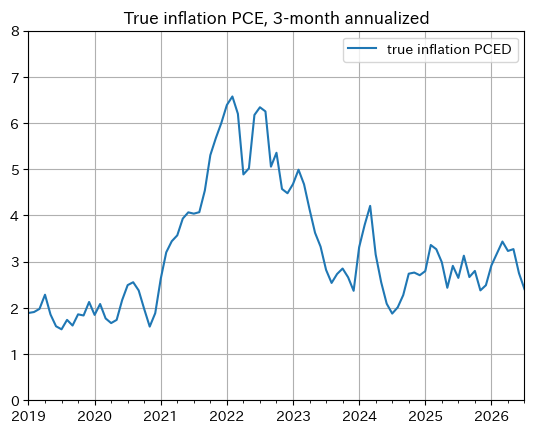

In [15]:
g_ann(true_inflation_pce, 3).loc['2019':].dropna().plot(
    grid=True,
    ylim=(0, 8),
    title='True inflation PCE, 3-month annualized'
)

<Axes: title={'center': 'True inflation PCE, year-over-year'}>

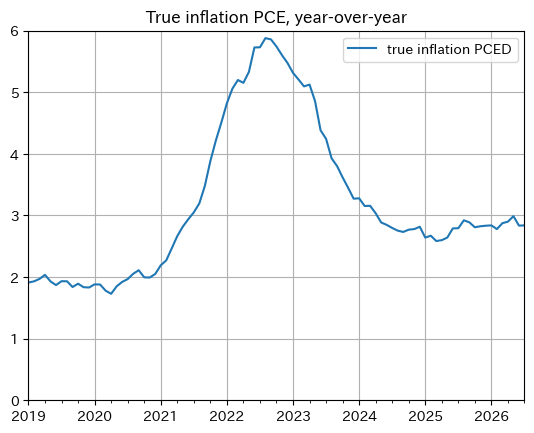

In [16]:
g_ann(true_inflation_pce, 12).loc['2019':].dropna().plot(
    grid=True,
    ylim=(0, 6),
    title='True inflation PCE, year-over-year'
)

## ウォーシュチャート

### 12. 品目別インフレ・マップ用データ

In [17]:

def make_item_inflation_map_data(
    arg_prices,
    target_date=None,
    indent_df=None
):
    """
    品目別の
      x = 前年比インフレ率
      y = 6か月前比年率インフレ率
    を1時点について作成する。

    target_date=None の場合は、両系列が利用可能な最新月を自動選択する。
    """
    prices = arg_prices.copy()

    if not isinstance(prices.index, pd.PeriodIndex):
        prices.index = pd.PeriodIndex(prices.index, freq='M')

    yoy = g_ann(prices, 12)
    sixm_ann = g_ann(prices, 6)

    if target_date is None:
        valid_dates = yoy.dropna(how='all').index.intersection(
            sixm_ann.dropna(how='all').index
        )

        if len(valid_dates) == 0:
            raise ValueError("No date has both YoY and 6-month annualized inflation data.")

        target_date = valid_dates.max()
    else:
        target_date = pd.Period(target_date, freq='M')

    if target_date not in yoy.index or target_date not in sixm_ann.index:
        raise ValueError(f"target_date={target_date} is outside the available sample.")

    out = pd.concat(
        [
            yoy.loc[target_date].rename('yoy'),
            sixm_ann.loc[target_date].rename('six_month_ann')
        ],
        axis=1
    ).dropna()

    out.index = out.index.astype(str).str.zfill(3)
    out.index.name = 'LineNumber'

    if indent_df is not None:
        desc = indent_df.copy()
        desc['LineNumber'] = desc['LineNumber'].astype(str).str.zfill(3)
        desc = desc.drop_duplicates('LineNumber').set_index('LineNumber')['LineDescription']
        out['LineDescription'] = out.index.map(desc)

    out.attrs['target_date'] = target_date

    return out

### 13. 前年比 × 6か月前比年率の散布図

In [71]:
def plot_item_inflation_scatter(
    arg_prices,
    target_date=None,
    thresholds=(2.5, 3.0),
    indent_df=None,
    xlim=None,
    ylim=None,
    figsize=(4, 4),
    s=35,
    alpha=0.70,
    grid=True
):
    """
    横軸：前年比インフレ率
    縦軸：6か月前比年率インフレ率

    thresholds の値に縦・横の点線を引く。

    Returns
    -------
    data : DataFrame
        当該月の品目別インフレ率。
    ax : matplotlib.axes.Axes
        描画したAxes。
    """
    data = make_item_inflation_map_data(
        arg_prices=arg_prices,
        target_date=target_date,
        indent_df=indent_df
    )

    target_date = data.attrs['target_date']

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        data['yoy'],
        data['six_month_ann'],
        s=s,
        alpha=alpha
    )

    for threshold in thresholds:
        ax.axvline(threshold, linestyle=':', linewidth=1.3)
        ax.axhline(threshold, linestyle=':', linewidth=1.3)

    ax.set_xlabel('前年比インフレ率（％）')
    ax.set_ylabel('6か月前比年率インフレ率（％）')
    ax.set_title(f'品目別インフレ率分布：{target_date}')

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(grid, alpha=0.25)
    plt.tight_layout()

    return data, ax

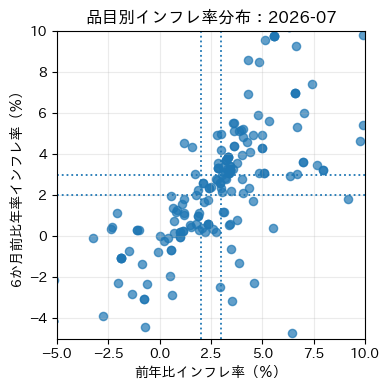

In [72]:
inflation_map_data, ax = plot_item_inflation_scatter(
    arg_prices=prices_items,
    target_date=None,     # 最新月
    thresholds=(2.0, 3.0),
    indent_df=indent_df,
    xlim=(-5, 10),
    ylim=(-5, 10)
)

### 14. 9領域の品目数・構成比

In [44]:
def make_item_inflation_region_table(
    arg_prices,
    target_date=None,
    thresholds=(2.0, 3.0),
    indent_df=None
):
    """
    前年比と6か月前比年率をそれぞれ
      1) < lower
      2) lower以上 upper未満
      3) >= upper
    に分け、3×3=9領域の品目数と全体に占める割合を返す。
    あわせて縦計・横計・総計を追加する。
    """
    lower, upper = sorted(thresholds)

    data = make_item_inflation_map_data(
        arg_prices=arg_prices,
        target_date=target_date,
        indent_df=indent_df
    )

    x_labels = [
        f'前年比 < {lower:.1f}%',
        f'{lower:.1f}% <= 前年比 < {upper:.1f}%',
        f'前年比 >= {upper:.1f}%'
    ]

    y_labels = [
        f'6か月年率 < {lower:.1f}%',
        f'{lower:.1f}% <= 6か月年率 < {upper:.1f}%',
        f'6か月年率 >= {upper:.1f}%'
    ]

    data = data.copy()

    data['x_region'] = pd.cut(
        data['yoy'],
        bins=[-np.inf, lower, upper, np.inf],
        right=False,
        labels=x_labels
    )

    data['y_region'] = pd.cut(
        data['six_month_ann'],
        bins=[-np.inf, lower, upper, np.inf],
        right=False,
        labels=y_labels
    )

    full_index = pd.MultiIndex.from_product(
        [x_labels, y_labels],
        names=['x_region', 'y_region']
    )

    counts = (
        data.groupby(['x_region', 'y_region'], observed=False)
        .size()
        .reindex(full_index, fill_value=0)
    )

    total = len(data)

    out = counts.rename('item_count').reset_index()
    out['share_pct'] = out['item_count'] / total * 100

    # 横計：各 y_region について x_region を合計
    y_totals = (
        out.groupby('y_region', observed=False)['item_count']
        .sum()
        .reindex(y_labels)
        .reset_index()
    )
    y_totals['x_region'] = '計'
    y_totals['share_pct'] = y_totals['item_count'] / total * 100

    # 縦計：各 x_region について y_region を合計
    x_totals = (
        out.groupby('x_region', observed=False)['item_count']
        .sum()
        .reindex(x_labels)
        .reset_index()
    )
    x_totals['y_region'] = '計'
    x_totals['share_pct'] = x_totals['item_count'] / total * 100

    # 総計
    grand_total = pd.DataFrame({
        'x_region': ['計'],
        'y_region': ['計'],
        'item_count': [total],
        'share_pct': [100.0]
    })

    out = pd.concat(
        [out, y_totals, x_totals, grand_total],
        ignore_index=True
    )

    # pivot 時に「計」を最後にする
    out['x_region'] = pd.Categorical(
        out['x_region'],
        categories=x_labels + ['計'],
        ordered=True
    )

    out['y_region'] = pd.Categorical(
        out['y_region'],
        categories=y_labels + ['計'],
        ordered=True
    )

    out.attrs['target_date'] = data.attrs.get('target_date')
    out.attrs['n_items'] = total

    return out

In [45]:
inflation_region_table = make_item_inflation_region_table(
    arg_prices=prices_items,
    target_date=None,
    thresholds=(2.0, 3.0),
    indent_df=indent_df
)

inflation_region_matrix = inflation_region_table.pivot(
    index='y_region',
    columns='x_region',
    values=['item_count', 'share_pct']
)

inflation_region_matrix

item_count                                        \
x_region             前年比 < 2.0% 2.0% <= 前年比 < 3.0% 前年比 >= 3.0%      計   
y_region                                                                
6か月年率 < 2.0%               72.0               11.0        17.0  100.0   
2.0% <= 6か月年率 < 3.0%        2.0               10.0         9.0   21.0   
6か月年率 >= 3.0%               8.0                6.0        92.0  106.0   
計                          82.0               27.0       118.0  227.0   

                      share_pct                                             
x_region             前年比 < 2.0% 2.0% <= 前年比 < 3.0% 前年比 >= 3.0%           計  
y_region                                                                    
6か月年率 < 2.0%          31.718062           4.845815    7.488987   44.052863  
2.0% <= 6か月年率 < 3.0%   0.881057           4.405286    3.964758    9.251101  
6か月年率 >= 3.0%          3.524229           2.643172   40.528634   46.696035  
計                     36.123348          11.894273   51.982379  100.000000

### 15. 前年比 × 6か月前比年率のヒートマップ

In [61]:
def plot_item_inflation_heatmap(
    arg_prices,
    target_date=None,
    thresholds=(2.0, 3.0),
    indent_df=None,
    bins=60,
    smooth=2.0,
    levels=12,
    figsize=(6, 4)
):
    """
    横軸：前年比インフレ率
    縦軸：6か月前比年率

    品目分布の密度を、真上から見た等高線図として表示する。
    """

    from scipy.ndimage import gaussian_filter

    lower, upper = sorted(thresholds)

    data = make_item_inflation_map_data(
        arg_prices=arg_prices,
        target_date=target_date,
        indent_df=indent_df
    )

    x = data['yoy'].to_numpy()
    y = data['six_month_ann'].to_numpy()

    # --------------------------------------------------
    # 2次元ヒストグラム
    # --------------------------------------------------
    density, x_edges, y_edges = np.histogram2d(
        x,
        y,
        bins=bins
    )

    # 密度を平滑化
    density = gaussian_filter(
        density,
        sigma=smooth
    )

    # ビン中心
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2

    X, Y = np.meshgrid(
        x_centers,
        y_centers
    )

    # histogram2d の向きを contour 用に転置
    Z = density.T

    # --------------------------------------------------
    # plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # 面としての密度
    cf = ax.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='cool' #'viridis'
    )

    # 等高線
    cs = ax.contour(
        X,
        Y,
        Z,
        levels=levels,
        colors='black',
        linewidths=0.5,
        alpha=0.6
    )

    ax.clabel(
        cs,
        inline=True,
        fontsize=7,
        fmt='%.1f'
    )

    # 閾値
    for v in (lower, upper):
        ax.axvline(
            v,
            color='black',
            linestyle='--',
            linewidth=1
        )
        ax.axhline(
            v,
            color='black',
            linestyle='--',
            linewidth=1
        )

    ax.set_xlabel('前年比インフレ率（％）')
    ax.set_ylabel('6か月前比年率（％）')

    ax.set_title(
        f'品目別インフレ率の密度分布 '
        f'({data.attrs["target_date"]})'
    )

    ax.grid(False)

    cbar = fig.colorbar(
        cf,
        ax=ax
    )
    cbar.set_label('品目密度')

    plt.tight_layout()
    plt.show()

    return data

In [65]:
def plot_item_inflation_heatmap_zoom(
    arg_prices,
    zoom_min=1.5,
    zoom_max=3.5,
    target_date=None,
    thresholds=(2.0, 3.0),
    indent_df=None,
    grid_size=200,
    figsize=(6, 4)
):
    """
    品目別インフレ率の2次元密度分布を、
    指定範囲だけ高解像度で拡大表示する。

    横軸：前年比インフレ率
    縦軸：6か月前比年率

    zoom_min, zoom_max は両軸共通。
    """

    from scipy.stats import gaussian_kde

    data = make_item_inflation_map_data(
        arg_prices=arg_prices,
        target_date=target_date,
        indent_df=indent_df
    )

    x = data['yoy'].to_numpy()
    y = data['six_month_ann'].to_numpy()

    # 全品目を使ってKDEを推計
    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    # 指定範囲だけ細かいグリッドで評価
    xx = np.linspace(zoom_min, zoom_max, grid_size)
    yy = np.linspace(zoom_min, zoom_max, grid_size)

    X, Y = np.meshgrid(xx, yy)

    positions = np.vstack([
        X.ravel(),
        Y.ravel()
    ])

    Z = kde(positions).reshape(X.shape)

    fig, ax = plt.subplots(figsize=figsize)

    cf = ax.contourf(
        X,
        Y,
        Z,
        levels=30,
        cmap='cool'  #'viridis'
    )

    ax.contour(
        X,
        Y,
        Z,
        levels=15,
        colors='black',
        linewidths=0.5,
        alpha=0.6
    )

    # 2.5%, 3.0%等の基準線
    for v in thresholds:
        if zoom_min <= v <= zoom_max:
            ax.axvline(
                v,
                color='black',
                linestyle='--',
                linewidth=1
            )

            ax.axhline(
                v,
                color='black',
                linestyle='--',
                linewidth=1
            )

    ax.set_xlim(zoom_min, zoom_max)
    ax.set_ylim(zoom_min, zoom_max)

    ax.set_xlabel('前年比インフレ率（％）')
    ax.set_ylabel('6か月前比年率（％）')

    ax.set_title(
        f'品目別インフレ率の密度分布・拡大 '
        f'({data.attrs["target_date"]})'
    )

    ax.grid(False)

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label('密度')

    plt.tight_layout()
    plt.show()

    return data

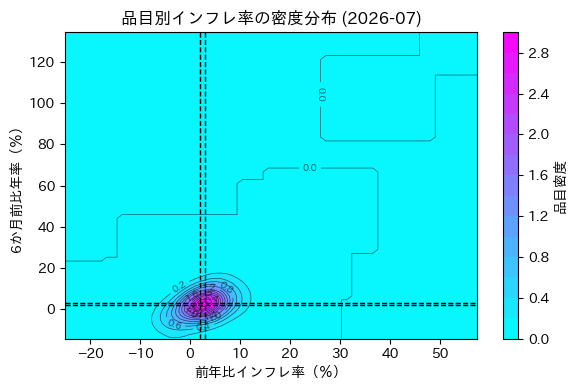

,yoy,six_month_ann,LineDescription
LineNumber,,,
007,1.145723,0.236819,New domestic autos
008,1.146210,0.236747,New foreign autos
010,0.569961,-0.684753,New domestic light trucks
011,0.569918,-0.684703,New foreign light trucks
014,-1.856752,-1.059235,Net transactions in used autos
...,...,...,...
351,1.015606,-0.053050,"Religious organizations, gross output"
352,2.952792,2.609747,Foundations and grantmaking and giving establi...
353,3.360349,3.243017,"Social advocacy establishments, gross output"


In [66]:
plot_item_inflation_heatmap(
    prices_items,
    bins=80,
    smooth=2.5,
    levels=15,
    indent_df=indent_df
)

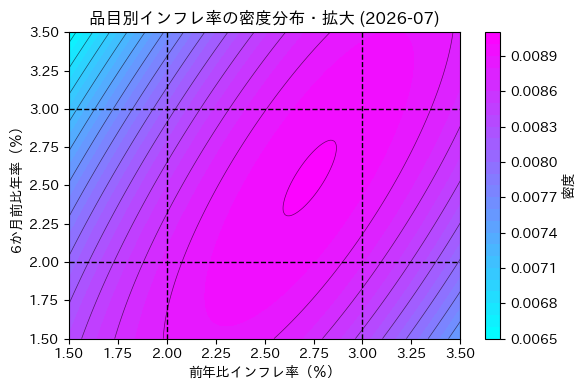

,yoy,six_month_ann,LineDescription
LineNumber,,,
007,1.145723,0.236819,New domestic autos
008,1.146210,0.236747,New foreign autos
010,0.569961,-0.684753,New domestic light trucks
011,0.569918,-0.684703,New foreign light trucks
014,-1.856752,-1.059235,Net transactions in used autos
...,...,...,...
351,1.015606,-0.053050,"Religious organizations, gross output"
352,2.952792,2.609747,Foundations and grantmaking and giving establi...
353,3.360349,3.243017,"Social advocacy establishments, gross output"


In [67]:
plot_item_inflation_heatmap_zoom(
    prices_items,
    zoom_min=1.5,
    zoom_max=3.5,
    indent_df=indent_df
)

中心は前年比より6か月率の方が低い<br>
→ <strong>中央部分ではdisinflation</strong><br>
6か月率の横断面分散が大きい<br>
→ <strong>品目間のインフレ率のばらつきは依然大きく、一部では再加速も起きている</strong>

In [58]:
def plot_inflation_density_peak_path(
    arg_prices,
    start='2019-01',
    end=None,
    search_min=0.0,
    search_max=6.0,
    grid_size=150,
    target=2.0,
    thresholds=(2.5, 3.0),
    figsize=(4, 3)
):
    """
    各月について
        横軸 = 前年比インフレ率
        縦軸 = 6か月前比年率
    の2次元KDEを推計し、密度ピークの時間的な移動をプロットする。

    Returns
    -------
    peak_df : DataFrame
        各月のKDEピーク座標と2%点からの距離。
    """

    from scipy.stats import gaussian_kde

    # --------------------------------------------------
    # 品目別インフレ率
    # --------------------------------------------------
    yoy = g_ann(arg_prices, 12)
    six_month = g_ann(arg_prices, 6)

    dates = yoy.index.intersection(six_month.index)

    start = pd.Period(start, freq='M')
    dates = dates[dates >= start]

    if end is not None:
        end = pd.Period(end, freq='M')
        dates = dates[dates <= end]

    # --------------------------------------------------
    # KDE評価用グリッド
    # --------------------------------------------------
    xx = np.linspace(search_min, search_max, grid_size)
    yy = np.linspace(search_min, search_max, grid_size)

    X, Y = np.meshgrid(xx, yy)

    positions = np.vstack([
        X.ravel(),
        Y.ravel()
    ])

    results = []

    # --------------------------------------------------
    # 月ごとにKDEピークを推計
    # --------------------------------------------------
    for date in dates:

        df = pd.DataFrame({
            'yoy': yoy.loc[date],
            'six_month_ann': six_month.loc[date]
        }).dropna()

        if len(df) < 5:
            continue

        values = np.vstack([
            df['yoy'].to_numpy(),
            df['six_month_ann'].to_numpy()
        ])

        try:
            kde = gaussian_kde(values)

            Z = kde(positions).reshape(X.shape)

            peak_idx = np.unravel_index(
                np.argmax(Z),
                Z.shape
            )

            peak_x = X[peak_idx]
            peak_y = Y[peak_idx]

        except np.linalg.LinAlgError:
            continue

        results.append({
            'date': date,
            'peak_yoy': peak_x,
            'peak_6m_ann': peak_y,
            'distance_from_target': np.sqrt(
                (peak_x - target) ** 2
                + (peak_y - target) ** 2
            )
        })

    peak_df = (
        pd.DataFrame(results)
        .set_index('date')
    )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # ピークの軌跡
    ax.plot(
        peak_df['peak_yoy'],
        peak_df['peak_6m_ann'],
        linewidth=1.5,
        alpha=0.7
    )

    # 月ごとの位置
    sc = ax.scatter(
        peak_df['peak_yoy'],
        peak_df['peak_6m_ann'],
        c=np.arange(len(peak_df)),
        cmap='viridis',
        s=35,
        zorder=3
    )

    # 開始点
    ax.scatter(
        peak_df['peak_yoy'].iloc[0],
        peak_df['peak_6m_ann'].iloc[0],
        s=120,
        marker='o',
        edgecolor='black',
        facecolor='none',
        linewidth=1.5,
        zorder=4
    )

    # 最新点
    ax.scatter(
        peak_df['peak_yoy'].iloc[-1],
        peak_df['peak_6m_ann'].iloc[-1],
        s=150,
        marker='*',
        edgecolor='black',
        linewidth=1,
        zorder=5
    )

    # 45度線
    ax.plot(
        [search_min, search_max],
        [search_min, search_max],
        linestyle=':',
        linewidth=1,
        color='black'
    )

    # 2%ターゲット
    ax.scatter(
        target,
        target,
        marker='X',
        s=120,
        color='black',
        label=f'{target:g}% point',
        zorder=5
    )

    # 2.5%, 3.0%の基準線
    for v in thresholds:
        ax.axvline(
            v,
            linestyle='--',
            linewidth=0.8,
            color='black',
            alpha=0.6
        )

        ax.axhline(
            v,
            linestyle='--',
            linewidth=0.8,
            color='black',
            alpha=0.6
        )

    ax.set_xlim(search_min, search_max)
    ax.set_ylim(search_min, search_max)

    ax.set_xlabel('前年比インフレ率（％）')
    ax.set_ylabel('6か月前比年率（％）')

    ax.set_title(
        '品目別インフレ率分布：密度ピークの軌跡'
    )

    ax.grid(True, alpha=0.3)

    # 時間を示すカラーバー
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('時間 →')

    plt.tight_layout()
    plt.show()

    return peak_df

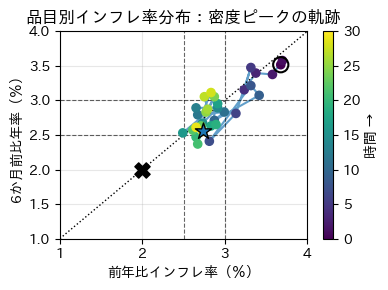

In [59]:
peak_df = plot_inflation_density_peak_path(
    prices_items,
    start='2024-01',
    search_min=1.0,
    search_max=4.0
)

<Axes: title={'center': '2%点からのKDEピークの距離'}, xlabel='date'>

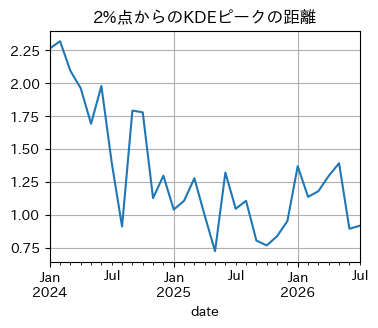

In [60]:
peak_df['distance_from_target'].plot(
    grid=True,
    title='2%点からのKDEピークの距離',
    figsize=(4,3)
)

In [68]:
def plot_high_inflation_share(
    arg_prices,
    months,
    threshold=3.0,
    start=None,
    figsize=(4, 3)
):
    """
    指定した月数の変化率（年率換算）を品目別に計算し、
    threshold以上の品目が全品目に占める割合をプロットする。

    Parameters
    ----------
    arg_prices : DataFrame
        品目別価格指数。行=月、列=品目。
    months : int
        変化率を計算する月数。
        例：3 → 3か月前比年率
            6 → 6か月前比年率
            12 → 前年比
    threshold : float, default 3.0
        判定するインフレ率の閾値（％）。
    start : str or None
        グラフの開始時点。例 '2019-01'
    figsize : tuple
        グラフサイズ。

    Returns
    -------
    item_inflation : DataFrame
        品目別インフレ率。
    high_inflation_share : Series
        threshold以上の品目割合（％）。
    """

    # 品目別インフレ率
    item_inflation = g_ann(arg_prices, months)

    # 各月の有効品目数
    n_valid = item_inflation.notna().sum(axis=1)

    # threshold以上の品目数
    n_high = (item_inflation >= threshold).sum(axis=1)

    # threshold以上の品目割合
    high_inflation_share = n_high / n_valid * 100
    high_inflation_share.name = f'share_ge_{threshold:g}'

    # 表示期間
    plot_data = high_inflation_share.dropna()

    if start is not None:
        plot_data = plot_data.loc[start:]

    # プロット
    fig, ax = plt.subplots(figsize=figsize)

    plot_data.plot(
        ax=ax,
        grid=True
    )

    ax.set_title(
        f'品目別インフレ率 {threshold:g}%以上の割合'
        f'（{months}か月前比年率）'
    )
    ax.set_ylabel('割合（％）')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

    return item_inflation, high_inflation_share

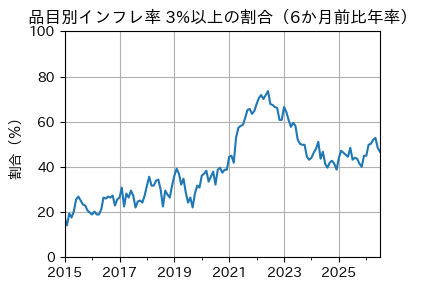

In [69]:
item_inflation_6m, share_ge_3_6m = plot_high_inflation_share(
    prices_items,
    months=6,
    threshold=3.0,
    start='2015-01'
)

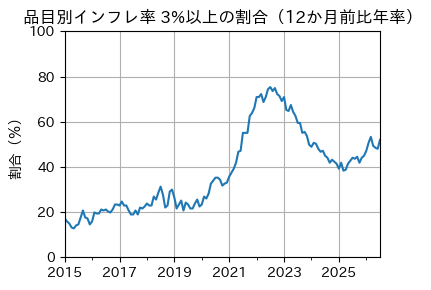

In [70]:
_,_  = plot_high_inflation_share(
    prices_items,
    months=12,
    threshold=3.0,
    start='2015-01'
)

In [28]:
item_inflation_6m.tail()

LineNumber,007,008,010,011,014,015,016,018,019,021,022,025,026,027,028,030,031,033,034,036,037,041,042,043,045,046,047,049,050,051,052,054,055,057,058,059,060,061,064,065,067,068,069,070,071,077,078,080,081,082,083,084,086,087,088,089,091,092,093,094,095,097,098,100,101,102,103,106,107,108,110,111,112,115,116,118,119,123,124,125,127,128,129,130,132,133,134,135,136,138,139,140,141,143,144,147,148,155,156,161,162,163,164,167,168,170,171,174,175,177,178,180,181,184,185,186,188,189,192,195,196,197,198,201,203,204,205,206,207,208,211,212,214,215,216,217,219,220,221,222,224,225,227,228,229,231,232,233,239,240,242,243,244,245,247,248,250,251,255,256,257,259,262,263,265,266,267,268,269,271,273,276,277,278,279,283,284,285,287,288,289,292,293,295,296,297,299,301,302,303,304,305,306,309,310,312,313,314,316,318,319,320,321,322,323,324,325,326,328,329,330,331,332,335,336,337,345,346,347,348,349,350,351,352,353,354,355
2026-03,2.522788,2.525382,0.805157,0.805097,-5.377576,-5.376269,15.941050,-5.377563,-5.377761,0.991623,0.823499,-0.216962,0.357638,7.687435,13.704917,-6.033416,-1.695110,18.265397,13.380403,7.805519,5.490324,-5.518069,7.319203,-2.414069,11.960066,22.878920,7.322733,0.868633,46.702679,-18.282368,5.490362,0.0,-2.081835,-2.081783,-2.081747,-2.081361,-7.467219,4.287675,17.541047,7.543773,2.412187,0.110077,2.435072,5.082355,-18.286339,2.953278,1.543543,8.589849,1.592359,-5.423048,3.557622,6.758849,-1.210555,-4.090511,-49.041073,-0.108865,1.824332,6.721302,2.837872,9.824142,1.987386,7.662067,2.013109,-1.265211,0.026035,2.879723,-8.911701,8.515902,1.453112,0.849034,7.072238,4.521903,1.833204,43.514319,-2.502689,95.086833,-3.779301,-3.094856,3.045286,2.410391,1.411848,3.810094,5.568209,4.219583,1.252287,-4.184075,8.211474,7.074016,3.159634,3.500656,1.046537,3.500656,7.434488,7.238773,-1.828438,1.500939,1.500849,2.049026,2.048953,2.750809,2.750809,2.751112,2.050765,6.136588,4.622725,4.938905,12.293846,1.992800,8.025048,1.688464,1.079250,8.552311,8.559810,3.420777,3.418969,3.419243,3.467366,3.467549,3.108577,-0.880616,-0.880859,15.941046,4.995018,5.178911,5.178078,11.861261,11.861381,5.178966,13.944631,5.178633,-4.424858,1.098217,11.400902,11.471629,1.922654,11.412443,0.381437,4.466880,1.762558,3.064440,34.436585,11.959070,3.766392,3.764881,3.765082,3.963265,1.101083,1.323469,1.980286,4.011422,3.711134,4.016026,4.013703,2.400233,4.012953,4.012867,4.371629,2.925814,7.718569,2.306011,2.576076,0.034170,15.858637,-0.142876,19.820817,16.081548,-5.781397,20.192837,45.756390,2.718959,0.906872,9.821928,3.765559,-2.164150,0.967681,1.087604,1.087635,-7.164907,3.242063,11.895687,4.519834,2.491551,2.493355,4.027930,2.582506,1.546592,4.355133,-13.444506,3.357838,1.573203,2.141522,4.349103,4.828420,3.549348,9.718899,5.203296,9.718772,9.719151,2.586040,0.084797,5.978303,4.648181,3.136424,4.026378,5.168843,2.921002,-1.132633,3.521181,15.614018,0.866888,3.458758,3.458365,-1.365402,7.884888,1.806374,1.806167,2.323084,2.384399,3.488160,1.154785,2.636880,4.178096,-1.131167,3.520537,4.203018,1.826722,1.964338
2026-04,1.920589,1.919999,0.369857,0.369830,-6.644434,-6.644221,7.961784,-6.644027,-6.644318,1.845103,0.719247,-0.892706,2.232838,3.403559,11.597780,-6.408367,-0.264366,28.537441,12.123043,4.404161,4.189995,-1.858961,1.368743,-0.440614,11.497464,26.178585,3.454420,5.508638,60.386386,-18.815372,5.419867,0.0,-0.027269,-0.027268,-0.027268,-0.028967,-14.184876,4.588384,21.479495,8.518439,0.100926,-0.034201,-0.564983,7.363898,-18.819059,2.520715,1.885178,11.644129,3.125253,-2.640220,1.292112,7.167074,2.733195,-0.870805,-41.273131,-1.624908,3.508352,17.107726,4.324331,5.680748,2.186766,7.691046,4.062170,-1.429459,-1.256153,2.964748,-6.201859,9.561413,3.086687,-3.177365,13.180406,5.931650,5.532153,64.553114,-4.523520,112.495070,1.970164,-3.016177,-0.838098,0.100926,3.508954,3.928558,3.121232,9.886373,-0.199903,-0.933252,1.220564,13.178078,2.768571,3.276019,4.843320,3.274315,6.818792,5.580700,5.657515,0.835736,0.834685,2.984520,2.985840,3.509519,3.510981,3.50

In [30]:
share_ge_3_6m.tail()

2026-03    50.220264
2026-04    51.982379
2026-05    52.863436
2026-06    48.458150
2026-07    46.696035
Freq: M, Name: share_ge_3, dtype: float64

# ここまで

In [ ]:
def weighted_quantile(values, weights, q):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        return np.nan

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cum_w = np.cumsum(weights)
    cum_w = cum_w / cum_w[-1]

    return np.interp(q, cum_w, values)

In [ ]:
def make_distribution_diagnostics(arg_prices, arg_nominals, horizon=3):
    """
    品目別インフレ分布の診断指標を作る。
    - weighted_median
    - share_above_2
    - share_above_3
    - share_below_0
    """

    item_infl = g_ann(arg_prices, horizon)

    w = arg_nominals.shift(1)
    w = w.div(w.sum(axis=1), axis=0)

    out = pd.DataFrame(index=item_infl.index)

    out['weighted_median'] = np.nan
    out['share_above_2'] = np.nan
    out['share_above_3'] = np.nan
    out['share_below_0'] = np.nan

    for t in item_infl.index:
        x = item_infl.loc[t]
        wt = w.loc[t]

        df = pd.concat([x, wt], axis=1)
        df.columns = ['infl', 'weight']
        df = df.dropna()
        df = df[df['weight'] > 0]

        if df.empty:
            continue

        df['weight'] = df['weight'] / df['weight'].sum()

        out.loc[t, 'weighted_median'] = weighted_quantile(
            df['infl'].values,
            df['weight'].values,
            0.50
        )

        out.loc[t, 'share_above_2'] = df.loc[df['infl'] > 2, 'weight'].sum()
        out.loc[t, 'share_above_3'] = df.loc[df['infl'] > 3, 'weight'].sum()
        out.loc[t, 'share_below_0'] = df.loc[df['infl'] < 0, 'weight'].sum()

    return out

In [ ]:
def evaluate_underlying_inflation_widths(
    arg_prices,
    arg_nominals,
    headline_index,
    lower_grid=[0.05, 0.10, 0.15, 0.20, 0.24, 0.25, 0.30],
    upper_grid=[0.05, 0.10, 0.15, 0.20, 0.24, 0.25, 0.30, 0.31, 0.35],
    signal_horizon=3,
    target_horizons=[12, 24, 36],
    sample_start='2010-01',
    max_total_trim=0.70
):
    """
    真の基調的インフレ率としての妥当性を評価する。

    評価軸：
    1. 中期ヘッドラインPCEへの不偏性
    2. ノイズ除去能力
    3. 転換点感応度
    4. 品目別インフレ分布との整合性
    5. サンプル安定性

    Dallas型の距離は使わない。
    """

    arg_prices = arg_prices.copy()
    arg_nominals = arg_nominals.copy()
    headline_index = headline_index.copy()

    if not isinstance(arg_prices.index, pd.PeriodIndex):
        arg_prices.index = pd.PeriodIndex(arg_prices.index, freq='M')

    if not isinstance(arg_nominals.index, pd.PeriodIndex):
        arg_nominals.index = pd.PeriodIndex(arg_nominals.index, freq='M')

    if not isinstance(headline_index.index, pd.PeriodIndex):
        headline_index.index = pd.PeriodIndex(headline_index.index, freq='M')

    sample_start = pd.Period(sample_start, freq='M')

    headline_signal = g_ann(headline_index, signal_horizon).iloc[:, [0]]
    headline_signal.columns = ['headline_signal']

    dist = make_distribution_diagnostics(
        arg_prices=arg_prices,
        arg_nominals=arg_nominals,
        horizon=signal_horizon
    )

    future_targets = {}

    for h in target_horizons:
        tmp = forward_ann(headline_index, h).iloc[:, [0]]
        tmp.columns = [f'future_headline_{h}m']
        future_targets[h] = tmp

    results = []

    # 転換点判定用
    headline_change = headline_signal['headline_signal'].diff()
    accel_threshold = headline_change.quantile(0.75)
    decel_threshold = headline_change.quantile(0.25)

    for lower_trim in lower_grid:
        for upper_trim in upper_grid:

            if lower_trim + upper_trim >= 1:
                continue

            if lower_trim + upper_trim > max_total_trim:
                continue

            label = f'trim_{int(lower_trim * 100)}_{int(upper_trim * 100)}'

            trimmed_index = make_trimmed_mean_pce(
                arg_prices=arg_prices,
                arg_nominals=arg_nominals,
                lower_trim=lower_trim,
                upper_trim=upper_trim,
                label=label
            )

            signal = g_ann(trimmed_index, signal_horizon).iloc[:, [0]]
            signal.columns = ['signal']

            df = pd.concat(
                [signal, headline_signal, dist] + list(future_targets.values()),
                axis=1,
                join='inner'
            )

            df = df.loc[sample_start:, :].dropna()

            if df.empty:
                continue

            # 1. 中期ヘッドラインPCEへの不偏性
            future_bias_abs_list = []
            future_mae_list = []
            future_rmse_list = []

            for h in target_horizons:
                col = f'future_headline_{h}m'
                err = df['signal'] - df[col]

                future_bias_abs_list.append(abs(err.mean()))
                future_mae_list.append(err.abs().mean())
                future_rmse_list.append(np.sqrt((err ** 2).mean()))

            future_bias_abs_mean = np.mean(future_bias_abs_list)
            future_mae_mean = np.mean(future_mae_list)
            future_rmse_mean = np.mean(future_rmse_list)

            # 2. ノイズ除去能力
            headline_vol = df['headline_signal'].std()
            signal_vol = df['signal'].std()

            headline_abs_change = df['headline_signal'].diff().abs().mean()
            signal_abs_change = df['signal'].diff().abs().mean()

            noise_ratio = signal_vol / headline_vol
            change_ratio = signal_abs_change / headline_abs_change

            # 3. 転換点感応度
            d_headline = df['headline_signal'].diff()
            d_signal = df['signal'].diff()

            accel_months = d_headline >= accel_threshold
            decel_months = d_headline <= decel_threshold

            accel_miss = (
                d_headline.loc[accel_months]
                - d_signal.loc[accel_months]
            ).clip(lower=0).mean()

            decel_miss = (
                d_signal.loc[decel_months]
                - d_headline.loc[decel_months]
            ).clip(lower=0).mean()

            turning_miss = np.nanmean([accel_miss, decel_miss])

            # 4. 品目別インフレ分布との整合性
            corr_median = df[['signal', 'weighted_median']].corr().iloc[0, 1]
            corr_share_above_3 = df[['signal', 'share_above_3']].corr().iloc[0, 1]

            high_breadth_low_signal = (
                (df['share_above_3'] >= 0.60)
                & (df['signal'] < 3.0)
            ).mean()

            low_breadth_high_signal = (
                (df['share_above_3'] <= 0.30)
                & (df['signal'] > 3.0)
            ).mean()

            breadth_mismatch = high_breadth_low_signal + low_breadth_high_signal

            # 5. サンプル安定性
            windows = [
                ('pre_covid', '2010-01', '2019-12'),
                ('covid_after', '2020-01', None)
            ]

            window_biases = []
            window_vols = []

            for _, start, end in windows:
                start_p = pd.Period(start, freq='M')

                if end is None:
                    dfi = df.loc[start_p:, :].copy()
                else:
                    end_p = pd.Period(end, freq='M')
                    dfi = df.loc[start_p:end_p, :].copy()

                if dfi.empty:
                    continue

                h = target_horizons[0]
                err_i = dfi['signal'] - dfi[f'future_headline_{h}m']

                window_biases.append(err_i.mean())
                window_vols.append(dfi['signal'].std())

            if len(window_biases) >= 2:
                stability_bias = np.nanstd(window_biases)
                stability_vol = np.nanstd(window_vols)
            else:
                stability_bias = np.nan
                stability_vol = np.nan

            results.append({
                'lower_trim': lower_trim,
                'upper_trim': upper_trim,
                'total_trim': lower_trim + upper_trim,
                'kept_share': 1 - lower_trim - upper_trim,

                # 1. 中期ヘッドラインPCEへの不偏性
                'future_bias_abs_mean': future_bias_abs_mean,
                'future_mae_mean': future_mae_mean,
                'future_rmse_mean': future_rmse_mean,

                # 2. ノイズ除去能力
                'signal_vol': signal_vol,
                'headline_vol': headline_vol,
                'noise_ratio': noise_ratio,
                'signal_abs_change': signal_abs_change,
                'headline_abs_change': headline_abs_change,
                'change_ratio': change_ratio,

                # 3. 転換点感応度
                'turning_miss': turning_miss,
                'accel_miss': accel_miss,
                'decel_miss': decel_miss,

                # 4. 分布整合性
                'corr_median': corr_median,
                'corr_share_above_3': corr_share_above_3,
                'breadth_mismatch': breadth_mismatch,

                # 5. サンプル安定性
                'stability_bias': stability_bias,
                'stability_vol': stability_vol,

                'nobs': df.shape[0]
            })

    out = pd.DataFrame(results)

    if out.empty:
        raise ValueError("No valid trim candidates.")

    # ランキング化
    out['rank_bias'] = out['future_bias_abs_mean'].rank(method='min')
    out['rank_mae'] = out['future_mae_mean'].rank(method='min')

    out['rank_noise_ratio'] = out['noise_ratio'].rank(method='min')
    out['rank_change_ratio'] = out['change_ratio'].rank(method='min')

    out['rank_turning_miss'] = out['turning_miss'].rank(method='min')

    out['rank_corr_median'] = (-out['corr_median']).rank(method='min')
    out['rank_corr_share_above_3'] = (-out['corr_share_above_3']).rank(method='min')
    out['rank_breadth_mismatch'] = out['breadth_mismatch'].rank(method='min')

    out['rank_stability_bias'] = out['stability_bias'].rank(method='min')
    out['rank_stability_vol'] = out['stability_vol'].rank(method='min')

    # 絶対的検証用スコア
    out['score'] = (
        # 中期ヘッドラインへの不偏性
        0.20 * out['rank_bias']
        + 0.10 * out['rank_mae']

        # ノイズ除去
        + 0.10 * out['rank_noise_ratio']
        + 0.10 * out['rank_change_ratio']

        # 転換点
        + 0.20 * out['rank_turning_miss']

        # 分布整合性
        + 0.10 * out['rank_corr_median']
        + 0.05 * out['rank_corr_share_above_3']
        + 0.05 * out['rank_breadth_mismatch']

        # サンプル安定性
        + 0.05 * out['rank_stability_bias']
        + 0.05 * out['rank_stability_vol']
    )

    return out.sort_values('score').reset_index(drop=True)

In [ ]:
trim_eval = evaluate_underlying_inflation_widths(
    arg_prices=prices_items,
    arg_nominals=nominals_items,
    headline_index=headline_pce,
    lower_grid=[0.05, 0.10, 0.15, 0.20, 0.24, 0.25, 0.30],
    upper_grid=[0.05, 0.10, 0.15, 0.20, 0.24, 0.25, 0.30, 0.31, 0.35],
    signal_horizon=3,
    target_horizons=[12, 24, 36],
    sample_start='2010-01',
    max_total_trim=0.70
)

cols_show = [
    'lower_trim',
    'upper_trim',
    'total_trim',
    'kept_share',
    'score',
    'future_bias_abs_mean',
    'future_mae_mean',
    'noise_ratio',
    'change_ratio',
    'turning_miss',
    'corr_median',
    'corr_share_above_3',
    'breadth_mismatch',
    'stability_bias',
    'stability_vol',
    'nobs'
]

trim_eval.loc[:, cols_show].head(20)

In [ ]:
near_optimal = trim_eval[
    trim_eval['score'] <= trim_eval['score'].min() + 3
].copy()

near_optimal.loc[:, cols_show]

In [ ]:
top_n = 5

series_list = []

for i in range(top_n):
    lower_trim = trim_eval.loc[i, 'lower_trim']
    upper_trim = trim_eval.loc[i, 'upper_trim']

    tmp = make_trimmed_mean_pce(
        arg_prices=prices_items,
        arg_nominals=nominals_items,
        lower_trim=lower_trim,
        upper_trim=upper_trim,
        label=f'trim {int(lower_trim*100)}/{int(upper_trim*100)}'
    )

    series_list.append(tmp)

top_trimmed = pd.concat(series_list, axis=1)

g_ann(top_trimmed, 3).loc['2019':].dropna().plot(
    grid=True,
    ylim=(0, 8),
    title='Top underlying PCE candidates'
)

In [ ]:
best_lower = trim_eval.loc[0, 'lower_trim']
best_upper = trim_eval.loc[0, 'upper_trim']

true_inflation_pce = make_trimmed_mean_pce(
    arg_prices=prices_items,
    arg_nominals=nominals_items,
    lower_trim=best_lower,
    upper_trim=best_upper,
    label='true inflation PCED'
)

print(f"lower trim = {best_lower:.0%}")
print(f"upper trim = {best_upper:.0%}")
print(f"kept share = {1 - best_lower - best_upper:.0%}")

g_ann(true_inflation_pce, 3).loc['2019':].dropna().plot(
    grid=True,
    ylim=(0, 8),
    title='Selected underlying PCE inflation'
)

In [ ]:
series_list = []

for i in near_optimal.index:
    lower_trim = near_optimal.loc[i, 'lower_trim']
    upper_trim = near_optimal.loc[i, 'upper_trim']

    tmp = make_trimmed_mean_pce(
        arg_prices=prices_items,
        arg_nominals=nominals_items,
        lower_trim=lower_trim,
        upper_trim=upper_trim,
        label=f'trim {int(lower_trim*100)}/{int(upper_trim*100)}'
    )

    series_list.append(tmp)

range_trimmed = pd.concat(series_list, axis=1)

In [ ]:
range_ann = g_ann(range_trimmed, 3).loc['2019':].dropna(how='all')

best_ann = g_ann(true_inflation_pce, 3).loc['2019':].dropna()
best_ann = best_ann.iloc[:, 0]
best_ann.name = 'selected'

x = range_ann.index.to_timestamp()

range_min = range_ann.min(axis=1)
range_max = range_ann.max(axis=1)
range_p25 = range_ann.quantile(0.25, axis=1)
range_p75 = range_ann.quantile(0.75, axis=1)
range_mean = range_ann.mean(axis=1)

plt.figure(figsize=(10, 6))

# 全候補レンジ
plt.fill_between(
    x,
    range_min.astype(float),
    range_max.astype(float),
    alpha=0.15,
    label='near-optimal full range'
)

# 中央50％レンジ
#plt.fill_between(
#    x,
#    range_p25.astype(float),
#    range_p75.astype(float),
#    alpha=0.30,
#    label='near-optimal interquartile range'
#)

# 候補平均
#plt.plot(
#    x,
#    range_mean.astype(float),
#    linewidth=1.8,
#    linestyle='--',
#    label='near-optimal mean'
#)

# 採用系列
plt.plot(
    best_ann.index.to_timestamp(),
    best_ann.astype(float),
    linewidth=2.8,
    label='selected indicator'
)

plt.axhline(2, linewidth=1, linestyle=':', label='2%')

plt.grid(False)
plt.ylim(0, 8)
plt.title('Underlying PCE inflation: selected indicator and near-optimal range')
plt.legend()
plt.show()